In [1]:
from src.sam3.samgeo3 import SamGeo3
from typing import List
from src.sam3.samgeo3 import PredictionResult
from matplotlib import pyplot as plt

In [2]:
print("Initializing SamGeo3...")
sam = SamGeo3(model_id="data/sam3")

img_1 = "data/example/netivot1.tif"
img_2 = "data/example/netivot2.tif"

# Keys will be 'netivot1.tif' and 'netivot2.tif'
text_results = sam.predict_batch_text([img_1, img_2], prompts="building")

# Use the new results_to_gdf method
gdf = sam.results_to_gdf(text_results, simplify_tolerance=0)
if gdf is not None:
    print(f"Total features created: {len(gdf)}")

for img_id, res in text_results.items():
    print(f"Image {img_id}: Found {len(res['masks'])} objects.")

Initializing SamGeo3...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !
The OrderedVocab you are attempting to save contains holes for indices [1], your vocabulary could be corrupted !


SAM3 Text Batch: 100%|██████████| 1/1 [00:03<00:00,  3.78s/batch]


Total features created: 121
Image netivot1.tif: Found 24 objects.
Image netivot2.tif: Found 48 objects.


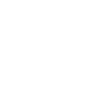

In [3]:
from shapely import MultiPolygon

MultiPolygon(gdf[gdf['image_id']==gdf.iloc[0,1]].geometry.to_list())

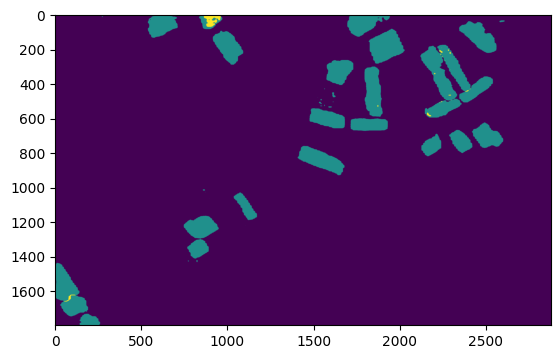

In [5]:
plt.imshow(sum(text_results['netivot1.tif']['masks']))